# Relativity Python coursework: Debugging report for CID 02404313

Replace the x's **in the title above** and **in the filename** with your CID number.  Do not include your name (the coursework will be marked anonymously).  You can rename the file in Jupyter notebooks by going to the File menu > Rename.

Fill in details of bugs you have found in the corresponding sections below. Make sure you fill in the correct section which corresponds to the section of code you found the bug in, otherwise you might not get credit for that bug. 

**Please make sure you read the PDF instructions on Blackboard to see what information you need to include for each bug.**

***Make sure you also add the additional information and explanations that the notebook directs you to add to the debugging report - these bits count for a significant fraction of the marks.***

The code you received probably does not have bugs in every section.  LEAVE BLANK any sections for which you did not find any bugs (that is, leave it as below - note that Jupyter notebooks might display "Type Markdown and LaTeX: $\alpha^2$" or similar when the cell is blank - this is okay!)

You can add extra cells in any of the sections below if you like, as appropriate, including adding additional subheadings. You can use code cells and/or markdown cells and/or copy-and-paste outputs across from your code notebook as appropriate. This notebook is just a report and will not be run, so (unlike for your code notebook which you also need to submit) you do not need to spend time making any code cells you include in this report executable. If it helps, you can include images such as screen snips. Please follow the instructions for the task which you can find in the M&R relativity folder on Blackboard - these include more detailed guidance about this.

**IMPORTANT: DO NOT EDIT THE TITLE OF ANY OF THE SECTIONS BELOW.**  **Penalties will be applied** in cases where the titles below are changed.  This is because your submission will be processed automatically prior to marking and these exact titles are part of the processing script.

### Bugs found in Section 1.1

The original code that was written, which I went on to correct:

In [ ]:
def findEProd_restframe(ma,mb,mc):
    return (ma**2-mc**2+mb**2)/(2*ma)

This function defines the energy of C incorrectly. For a particle interaction A -> B + C, in the rest frame of A, the energy of C is given by:

$\frac{(m_a^2+m_c^2-m_b^2)c^2}{2m_a}$

Therefore, I corrected the definition of the function to:

In [ ]:
def findEProd_restframe(ma,mb,mc):
    return (ma**2+mc**2-mb**2)/(2*ma)

where $c = 1$ in natural units. Also note that I changed the variables eM and eG to Me and Ge, respectively.

### Bugs found in Section 1.2

The original code snippets that were written, which I went on to correct:

In [ ]:
me=0.511e-3 
mnu_e=1.1e-6 

Enu_e_rf_pi=findEProd_rf(mpi,me,mnu_e)
print('Pi decay: nu energy ',Enu_e_rf_pi/Ge,' GeV')

Enu_e_rf_K=findEProd_rf(mK,me,mnu_e)
print(' K decay: nu energy ',Enu_e_rf_K/Ge,' GeV')

This had problems with units and was not returning sensible values. I corrected the masses to work in units of $MeV/c^2$, then to be converted back to $GeV$ for the final energies, as the code was attempting to do.

In [ ]:
#units MeV/c^2
me=511e3
mnu_e=1.1e-6

The code also didn't calculate all the energy values asked, and I changed from using Ge to dividing by one thousand instead. Note that I changed some variable names out of personal preference. The amended code was:

In [ ]:
Energy_neutrino_e_restframe_pi = findEProd_rf(mpi,me,mnu_e)
print('Pi decay: electron neutrino energy ',Energy_neutrino_e_restframe_pi/1e3,' GeV')

Energy_electron_restframe_pi = findEProd_rf(mpi,mnu_e,me)
print('Pi decay: electron energy ',Energy_electron_restframe_pi/1e3,' GeV')


Energy_neutrino_e_restframe_K = findEProd_rf(mK,me,mnu_e)
print(' K decay: electron neutrino energy ',Energy_neutrino_e_restframe_K/1e3,' GeV')

Energy_electron_restframe_K = findEProd_rf(mK,mnu_e,me)
print(' K decay: electron energy ',Energy_electron_restframe_K/1e3,' GeV')

This now returns sensible values in $GeV$, and contains all the energies asked for.

Next was to check that energy was conserved, so I added the code:

In [ ]:
if Energy_neutrino_e_restframe_pi + Energy_electron_restframe_pi == mpi:
    print('Energy is conserved for pion decay.')
    
if Energy_neutrino_e_restframe_K + Energy_electron_restframe_K == mK:
    print('Energy is conserved for kaon decay.')

This concluded that the rest energy of the pion/kaon equals the sum of the energies of the decay products. Hence, energy is conserved. If energy wasn't calculated to be conserved, the code wouldn't have returned any print statement.

### Bugs found in Section 1.3

The original code snippets that were written, which I went on to correct:

In [ ]:
mnu=0.19e-3

Enu_mu_rf_pi=findEProd_rf(mpi,mmu,mnu)
print('Pi decay: nu energy ',Enu_mu_rf_pi,' MeV')

Enu_mu_rf_K=findEProd_rf(mK,mmu,mnu)
print(' K decay: nu energy ',Enu_mu_rf_K,' MeV')

This had problems with units and was not returning sensible values. I corrected mnu to units of $MeV/c^2$:

In [2]:
mnu_mu=0.19

The code also didn't calculate all the energy values asked. Note that I again changed some variable names out of preference. I changed the code to:

In [ ]:
print('pi, K --> mu + nu_mu')

Energy_neutrino_mu_restframe_pi = findEProd_rf(mpi,mmu,mnu_mu)
print('Pi decay: muon neutrino energy ',Energy_neutrino_mu_restframe_pi,' MeV')

Energy_muon_restframe_pi = findEProd_rf(mpi,mnu_mu,mmu)
print('Pi decay: muon energy ',Energy_muon_restframe_pi,' MeV')


Energy_neutrino_mu_restframe_K = findEProd_rf(mK,mmu,mnu_mu)
print('K decay: muon neutrino energy ',Energy_neutrino_mu_restframe_K,' MeV')

Energy_muon_restframe_K = findEProd_rf(mK,mnu_mu,mmu)
print('K decay: muon energy ',Energy_muon_restframe_K,' MeV')


This now returns sensible values in $MeV$, and contains all the energies asked for.

Next was to check again that energy was conserved, so I added the code:

In [ ]:
if Energy_neutrino_mu_restframe_pi + Energy_muon_restframe_pi == mpi:
    print('Energy is conserved for pion decay.')
    
if Energy_neutrino_mu_restframe_K + Energy_muon_restframe_K == mK:
    print('Energy is conserved for kaon decay.')

This also concluded that the rest energy of the pion/kaon equals the sum of the energies of the decay products. Hence, energy is conserved.

### Bugs found in Section 1.4a

The original code that was written, which I went on to change:

In [ ]:
Enu_tau_rf_pi=findEProd_rf(mpi,mtau,mnu_tau)
print('Pi decay: nu energy ',Enu_tau_rf_pi,' MeV')

Enu_tau_rf_K=findEProd_rf(mK,mtau,mnu_tau)  
print(' K decay: nu energy ',Enu_tau_rf_K,' MeV')

The code also didn't calculate all the energy values asked for. Note that I again changed some variable names. I corrected to include kaon decay:

In [ ]:
Energy_neutrino_tau_restframe_pi = findEProd_rf(mpi,mtau,mnu_tau)
print('Pi decay: tau neutrino energy ',Energy_neutrino_tau_restframe_pi,' MeV')

Energy_tau_restframe_pi = findEProd_rf(mpi,mnu_tau,mtau)
print('Pi decay: tau energy ',Energy_tau_restframe_pi,' MeV')



Energy_neutrino_tau_restframe_K = findEProd_rf(mK,mtau,mnu_tau)  
print('K decay: tau neutrino energy ',Energy_neutrino_tau_restframe_K,' MeV')

Energy_tau_restframe_K = findEProd_rf(mK,mnu_tau,mtau)
print('K decay: tau energy ',Energy_tau_restframe_K,' MeV')

Note that this returns negative energies, so is not a possible interaction.

### Bugs found in Section 1.4b

Here, I had to add the energy of the tau particle:

In [ ]:
Energy_tau_restframe_Ds=findEProd_rf(mDs,mnu_tau,mtau)
print(Energy_tau_restframe_Ds,' MeV')

And to double check, although not asked for, I verified that energy was conserved to make sure the outputs made sense:

In [ ]:
if Energy_neutrino_tau_restframe_Ds + Energy_tau_restframe_Ds == mDs:
    print('Energy is conserved.')

(Energy was conserved, as expected.)

### Bugs found in Section 1.5a

Note I redefined energy variable names in the preliminary cells to this section.

The original code that was written, which I went on to correct:

In [ ]:
    return p*np.array([np.sin(phi)*np.cos(theta),np.sin(phi)*np.sin(theta),np.cos(phi)])

This had the wrong arguments in the trigonometric functions. The respective components of 3-momentum in spherical polars are:

$p_x = p\sin{\theta}\cos{\phi}, p_y = p\sin{\theta}\sin{\phi}, p_z = p\cos\theta$

So I corrected to:

In [ ]:
    return p*np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])

### Bugs found in Section 1.5b

I added the following variable reassignment:

In [ ]:
mnu=mnu_mu

The original code that was written, which I went on to correct:

In [ ]:
print('For theta=%.3f:' % (theta/np.pi))

I wanted to convert from radians to degrees for extra clarity when understanding code outputs, so I changed it to:

In [ ]:
print('For theta = %.3f:' % (theta*180/np.pi))
print('For phi = 0')

It then gave the correct value of $\theta = 30 ^{\circ}$. I also added a print statement for $\phi = 0$, and changed variable names for the momenta.

### Bugs found in Section 1.5c

The original code that was written, which I went on to correct:

In [ ]:
p_mu_rf_pi=find3mtmC_rf(mpi,mnu,mmu,((np.pi/2)-theta),1.*phi)
print('For pi decay: 3-mtm of nu in rf is ',p_nu_restframe_pi,' MeV/c')
print('For pi decay: 3-mtm of mu in rf is ',p_mu_rf_pi,' MeV/c')
print('For pi decay: total 3-mtm in rf is ',p_mu_rf_pi+p_nu_restframe_pi,' MeV/c \n')

p_mu_rf_K=find3mtmC_rf(mK,mnu,mmu,((np.pi/2)-theta),1.*phi)
print('For pi decay: 3-mtm of nu in rf is ',p_nu_restframe_K,' MeV/c')
print('For pi decay: 3-mtm of mu in rf is ',p_mu_rf_K,' MeV/c')
print('For pi decay: total 3-mtm in rf is ',p_mu_rf_K+p_nu_restframe_K,' MeV/c \n')

I corrected this to:

In [ ]:
p_mu_restframe_pi=find3mtmC_rf(mpi,mnu,mmu,theta,phi)
print('For pi decay: 3-mtm of nu in restframe is ',p_nu_restframe_pi,' MeV/c')
print('For pi decay: 3-mtm of mu in restframe is ',p_mu_restframe_pi,' MeV/c')
print('For pi decay: total 3-mtm in restframe is ',p_mu_restframe_pi-p_nu_restframe_pi,' MeV/c \n')

p_mu_restframe_K=find3mtmC_rf(mK,mnu,mmu,theta,phi)
print('For K decay: 3-mtm of nu in restframe is ',p_nu_restframe_K,' MeV/c')
print('For K decay: 3-mtm of mu in restframe is ',p_mu_restframe_K,' MeV/c')
print('For K decay: total 3-mtm in restframe is ',p_mu_restframe_K-p_nu_restframe_K,' MeV/c \n')

I redefined the momentum variables, and modified some of the print statements. I also changed the angle arguments, since they should still follow the normal spherical polars definition of $\theta$ and $\phi$. I also changed the + signs to - signs in the total momentum print statements, since the muon and neutrino will travel in opposite directions, and momentum is a vector quantity.

I also added if statements to check that the total momentum summed to zero:

In [ ]:
if np.allclose(p_mu_restframe_pi-p_nu_restframe_pi,np.array([0, 0, 0]),atol=1e-14):
    print('3-mtm is conserved for pion decay.')
    
if np.allclose(p_mu_restframe_K-p_nu_restframe_K,np.array([0, 0, 0]),atol=1e-14):
    print('3-mtm is conserved for kaon decay.')

The total momentum in the parent particle restframe is zero, as it is also the centre of mass frame. We know decay products will decay in opposite directions, so conclude that $p_{mu} = -p_{nu}$. The momenta should sum to zero after decay.

I had to employ the np.allclose function at a tolerance of $10^-14$, because the total momentum array for pion decay was showing very small non-zero values. This is likely due to the precision of values given in the project. However, it was close enough to zero to conclude that 3-momentum was conserved.

### Bugs found in Section 1.6

### Bugs found in Section 1.7

The original code that was written, that I went on to correct:


In [ ]:
    Enu=findEProd_rf(mpi,mmu,mnu)    
    p_nu=find3mtmC_rf(mpi,mmu,mnu,theta1,phi1) #mtm of product of decay
    return find4mtm(Enu,p_nu)

which was corrected to:

In [ ]:
    EC=findEProd_rf(mA,mB,mC)    
    pC=find3mtmC_rf(mA,mB,mC,theta1,phi1) #mtm of product of decay
    return find4mtm(EC,pC)

This keeps the functions general, so any A -> B + C interaction can be calculated.

### Bugs found in Section 1.8a

The original code snippets that were written, that I went on to correct:

In [ ]:
    thetaB=np.arctan2(mtm4B[2],mtm4B[1])
    
    phiB=np.arctan2(pxyB,mtm4B[3])

This had incorrect variable assignments. It was corrected to:

In [ ]:
    phiB=np.arctan2(mtm4B[2],mtm4B[1])
    
    thetaB=np.arctan2(pxyB,mtm4B[3])

This now calculates the angles using the correct arguments, namely such that $\theta = \arctan(\frac{p_{xy}}{p{z}})$ and $\phi = \arctan(\frac{p_{y}}{p{x}})$, where $p_{xy}$ is the x-y plane momentum $p_{xy} = \sqrt{p_x^2+p_y^2}$.

### Bugs found in Section 1.8b

The original code that I ammended was:

In [ ]:
print('muon (theta,phi)=(%.3f pi, %.3f pi) ' % (theta_pi/np.pi,phi_pi/np.pi) )


print('muon (theta,phi)=(%.3f pi, %.3f pi) ' % (theta_K/np.pi,phi_K/np.pi) )

I wanted to have outputs in degrees for extra clarity when trying to understand the outputs:

In [ ]:
print('muon (theta,phi)=(%.3f, %.3f) ' % (theta_pi*180/np.pi,phi_pi*180/np.pi) )


print('muon (theta,phi)=(%.3f, %.3f) ' % (theta_K*180/np.pi,phi_K*180/np.pi) )

Which yields:

PION DECAY:
muon (theta,phi)=(150.000, 180.000) 
KAON DECAY:
muon (theta,phi)=(150.000, 180.000) 

This agrees with the fact that the interaction happens in the plane y = 0. This also agrees with the fact that in part 1.5(b) it is mentioned that the neutrino has $\theta = 30^\circ$. The muon and neutrino hence travel in opposite directions as $180^\circ-30^\circ=150^\circ$, which agrees with 4-momentum conservation. This matches my expectation.

### Bugs found in Section 2.0a

The original code that I went on to change was:

In [ ]:
    v = np.sqrt(2*(E**2 - m**2)/m)
    return -v

This was incorrectly calculating $\beta$. In special relativity, the total energy of a particle $E$ is given by $E = \gamma mc^2$, where $\gamma = \frac{1}{\sqrt{1-\beta^2}}$, so we can simply use this. Hence, $\beta = \sqrt{1-\frac{(mc^2)^2}{E^2}}$. v for the particle's rest frame with respect to a particular lab frame can be considered to be a boost $+v$, so there is no need to have $v<0$. I corrected the code to:

In [ ]:
def findbeta(E,m):
    v = np.sqrt(1-m**2/E**2) #In natural units, c=1
    return v #equivalent to v/c in natural units

### Bugs found in Section 2.0b

The original code snippets which I went on to correct were:

In [ ]:
beta_lf_pi=0 #parent particle is at rest in rest frame! 
beta_lf_K=0 #parent particle is at rest in rest frame!

'from pi/K lab frame'

The parent particle may be at rest in its own rest frame, but that is not the concern of the question! Rather, it is moving with respect to the lab frame. The code was calculating beta_lf_pi and beta_lf_K wrongly. The print statements were also wrong. I corrected the code to:

In [ ]:
beta_lf_pi = -findbeta(EA_lf_pi,mpi)
beta_lf_K = -findbeta(EA_lf_K,mK)

'from pi/K rest frame'

This then returned sensible values. Minus signs were added to respect the convention of the lab frame moving at $-v$ with respect to a particle rest frame (i.e. a boost back to lab frame happens by $-v$, whereas the particle moves at $v$ with respect to the lab frame).

### Bugs found in Section 2.0c

The original code which I went on to correct was:

In [ ]:
tau_lf_pi = tau_rf_pi/(1-beta_lf_pi**2)


tau_lf_K = tau_rf_K/(1-beta_lf_K**2)

This was incorrectly calculating the lab frame lifetimes. The question says that the particles are observed to have certain lifetime in their restframes, meaning an experiment has been done in their restrames. The lab frame is moving at $-v$ with respect to the restframe. Hence, the time in the lab frame will be dilated with respect to their restframe times. We hence have to use the formula $\tau_{lf} = \gamma\tau_{rf}$. I corrected the code to:

In [ ]:
tau_lf_pi = tau_rf_pi*findgamma(beta_lf_pi)


tau_lf_K = tau_rf_K*findgamma(beta_lf_K)

This now calculates the correct values.

### Bugs found in Section 2.0d

### Bugs found in Section 2.1

The original code that I went on to correct was:

In [ ]:
plt.plot(E_lf, E_lf/r)
plt.xlabel(r'$E_{lf} (GeV)$', fontsize=24)
plt.ylabel(r'$E_{rf} (GeV)$', fontsize=24, rotation=0, labelpad=30)

I changed around the variables E_lf and E_rf in the arguments of plt.plot(). This is because it should be $E_{lf} = rE_{rf}$ because of the fact that $f = f'\sqrt{\frac{1+\beta}{1-\beta}}$. This means that $f_{lf} = f_{rf}\sqrt{\frac{1+\beta}{1-\beta}}$, where $\beta < 0$ as already defined for a boost back to lab frame. The graph needed to be $E_{lf}$ as a function of $E_{rf}$ as asked for. I hence changed the code to:

In [ ]:
plt.plot(E_rf, E_rf*r)
plt.xlabel(r'$E_{rf} (MeV)$', fontsize=12)
plt.ylabel(r'$E_{lf} (MeV)$', fontsize=12, rotation=90, labelpad=10)

With changes made to the label parameters for aesthetic reasons, and units in MeV. This returns a linear plot through the origin, as expected by the relationship $E_{lf} = rE_{rf}$, where $r$ is a constant.

### Bugs found in Section 2.2a

The original code that I went on to correct was:

In [ ]:
    m4b0=gamma_b*m4[0]-beta_b*gamma_b*m4[1]
    m4b3=gamma_b*m4[1]-beta_b*gamma_b*m4[0]

This was using the wrong components of the array m4. We want a boost in the +z direction, not the +x direction which the original code implies. This is so that it reflects the Lorentz transformations $E' = \gamma(E-\beta p_zc)$ and $p'_zc = \gamma(p_zc-\beta E)$. I changed the code to:

In [ ]:
    m4b0 = gamma_b*(m4[0]-beta_b*m4[3])
    m4b3 = gamma_b*(m4[3]-beta_b*m4[0])

### Bugs found in Section 2.2b

The original code that was written, which I went on to correct is listed as follows, with the respective versions for both pi and K decays.

In [ ]:
m4_nu_rf_pi=find4mtm(E_nu_restframe_pi*Ge,p_nu_restframe_pi)
v_nu_rf_pi = m4_nu_rf_pi[1:]/(mnu*findgamma(-beta_lf_pi)) 



m4_nu_rf_K=find4mtm(E_nu_restframe_K*Ge,p_nu_restframe_pi)
v_nu_rf_K = m4_nu_rf_K[1:]/(mnu*findgamma(-beta_lf_K)) 

This had an incorrect multiplier 'Ge', when everything is already in units of MeV. To find the restframe velocity, one had to use the formula $v = p/E$. The one used, $v = \frac{p}{\gamma m}$, is simply wrong, coming from an incorrect application of the gamma factor. The kaon decay, but not the pion decay, also used the wrong momentum in the argument of the find4mtm function - it should have been the one for K decay. The code was ammended to:

In [ ]:
m4_nu_rf_pi=find4mtm(E_nu_restframe_pi,p_nu_restframe_pi)
v_nu_rf_pi = m4_nu_rf_pi[1:]/(m4_nu_rf_pi[0])



m4_nu_rf_K=find4mtm(E_nu_restframe_K,p_nu_restframe_K)
v_nu_rf_K = m4_nu_rf_K[1:]/(m4_nu_rf_K[0])

The next code snippet that was wrong:

In [ ]:
v_nu_lf_pi_z = vz_rf*findgamma(-beta_lf_pi)



v_nu_lf_K_z = vz_rf*findgamma(-beta_lf_K)

Here, the code was attempting to do a relativistic velocity transformation, by assuming one could just multiply by the gamma factor. This was wrong. One had to use the formula for velocity addition, given by $u = \frac{v + u'}{1 + \frac{vu'}{c^2}}$, taking the primed frame as the rest frame and unprimed as the lab frame. For the pi and K decays, respectively, the code was ammended to:

In [ ]:
v_nu_lf_pi_z = (vz_rf-beta_lf_pi)/(1-vz_rf*beta_lf_pi)



v_nu_lf_K_z = (vz_rf2-beta_lf_K)/(1-vz_rf2*beta_lf_K)

The next code snippet that was wrong:

In [ ]:
v_nu_lf_pi2 = m4_nu_lf_pi[1:]/(mnu*findgamma(-beta_lf_pi)) 



v_nu_lf_K2 = m4_nu_lf_K[1:]/(mnu*findgamma(-beta_lf_K)) 

Again, this should have used the formula $v=p/E$. I changed it to:

In [ ]:
v_nu_lf_pi2 = m4_nu_lf_pi[3]/(m4_nu_lf_pi[0]) 



v_nu_lf_K2 = m4_nu_lf_K[3]/(m4_nu_lf_K[0]) 

The code then displayed the same result for both velocity addition and boosted 4-momentum, as expected. Also note that I changed all units from 'm/s' to 'c' in the print statements - e.g.:

In [ ]:
print('Pi neutrino Velocity lf from velocity addition', v_nu_lf_pi_z,' c')

Rather than:

In [ ]:
print('Pi neutrino Velocity lf from velocity addition', v_nu_lf_pi_z,' m/s')

### Bugs found in Section 2.2c

### Bugs found in Section 2.2d

Code snippets that were originally written, which I went on to correct was:

In [ ]:
phiC_lf_pi=np.arctan2(m4_nu_lf_pi[2],m4_nu_lf_pi[1])


print('neutrino theta (lf):',thetaC_lf_pi/np.pi,'pi')
print('neutrino phi (lf):  ',phiC_lf_pi/np.pi,'pi')


m4_pi_rf_pi=find4mtm(EA_lf_pi,np.array([0.,0.,0.]))


m4_pi_rf_K=find4mtm(EA_lf_pi,np.array([0.,0.,0.]))



For phiC_lf_pi the arguments were wrong. They should have been so that $tan\phi=p_y/p_x$. For all the print statements (not just the one given in the above cell - for concision's sake), I changed it to convert into degrees for extra intuition with regards to the angle sizes. The energies used to find the 4-momenta were wrong, and should have been the rest mass energies of the pion and kaon respectively, not the energies as viewed in the lab frame. These were 140 MeV and 490 MeV, respectively. I also changed the name m4_pi_rf_K to m4_K_rf_K, to make it an accurate name. The corrected code was:

In [ ]:
phiC_lf_pi=np.arctan2(m4_nu_lf_pi[2],m4_nu_lf_pi[1])


print('neutrino theta (lf):',thetaC_lf_pi*180/np.pi, 'degrees')
print('neutrino phi (lf):  ',phiC_lf_pi*180/np.pi, 'degrees')


m4_pi_rf_pi=find4mtm(140,np.array([0.,0.,0.]))


m4_K_rf_K=find4mtm(490,np.array([0.,0.,0.]))

The output matches my expectations because it shows the neutrino and muon travelling at an opening angle $<180^\circ$, as would instead have been in the rest frame of the decaying particle in question. The pion is also travelling at a greater speed than the kaon (because of its larger $\beta$), so the fact that it had a smaller opening angle makes sense. The output also matches the fact that there is no y-component, leading to $\phi$ values of either $0^\circ$ or $180^\circ$.

### Bugs found in Section 2.3

### Bugs found in Section 2.4

The original code that I went on to correct was:

In [ ]:
m4max_lf=find4mtm_C_lf(mpi,mmu,mnu,0.0,0.0,EA_lf_pi)
print('Max energy in lab frame (pi decay) [fn] is ',m4max_lf[0]*1e-3,' MeV') 

m4min_lf=find4mtm_C_lf(mpi,mmu,mnu,0.0,0.0,EA_lf_pi)
print('Min energy in lab frame (pi decay) [fn] is ',m4min_lf[0]*1e-3,' MeV') 

This had the wrong variable names - not what the question asked for. It also had a wrong multiplication factor of 1e-3 - we were already in MeV. It also had the wrong angles, and was producing the same value for the max and min energies. I ammended the code to:

In [ ]:
Enu_lf_pi_max = find4mtm_C_lf(mpi,mmu,mnu, 0,0.0,EA_lf_pi)
print('Max energy in lab frame (pi decay) [fn] is ',Enu_lf_pi_max[0],' MeV') 

Enu_lf_pi_min = find4mtm_C_lf(mpi,mmu,mnu,np.pi,0,EA_lf_pi)
print('Min energy in lab frame (pi decay) [fn] is ',Enu_lf_pi_min[0],' MeV')



Enu_lf_K_max = find4mtm_C_lf(mK,mmu,mnu,0,0.0,EA_lf_K)
print('Max energy in lab frame (K decay) [fn] is ',Enu_lf_K_max[0],' MeV') 

Enu_lf_K_min = find4mtm_C_lf(mK,mmu,mnu,np.pi,0,EA_lf_K)
print('Min energy in lab frame (K decay) [fn] is ',Enu_lf_K_min[0],' MeV') 

Now, this also included the K decay. The angles were $\theta=0$ or $\pi$, with $\phi=0$. This was to reflect the maximum possible/minimum possible angles, followed by a boost in the -z direction (forgetting the $\theta = 30^\circ$ given in part 1). I also got rid of the incorrect 1e-3 factors. Minimum energies were hence calculated using the max/min parallel/antiparallel angles - since due to symmetry, it is possible for the neutrini to have either, with energy and momentum still conserved.

### Bugs found in Section 3 Intro

### Bugs found in Section 3.0

The original code that was written, which I went on to change was (in snippets):

In [ ]:
def generate_theta_array(Narray=1):
   



        prob_theta = np.sin(thetanew) 
        
        thetavals = np.append(thetavals, thetanew[th1 < prob_theta])
        
        
        



distribn = generate_theta_array(Nevents)
plt.hist(distribn/np.pi, bins = Nbins)





plt.plot(xpi_range, y3,'r--',label=r'$sin(\theta)$')

plt.xlabel(r'$\theta/\pi$')
plt.ylabel('N')

The code did not closely enough resemble that from the part 3 preliminary example, so I modified this given code; as asked. I first added a proper domain definition, namely:

In [ ]:
theta_domain=[0,np.pi]

and then defined the distribution formally, and normalised it so that its integral over the domain was 1 (all probabilities must sum to 1 - Kolmolgorov axioms), making the prob_theta variable redundant:

In [ ]:
def theta_dist_normal(theta):
    return np.sin(theta)/2

I therefore changed the thetavals variable to:

In [ ]:
thetavals = np.append(thetavals, thetanew[th1 < theta_dist_normal(thetanew)])

The generate_theta_array function did not have the correct two positional arguments, so I modified it to reflect the previous example:

In [ ]:
def generate_theta_array(Narray, theta_domain):

I also specified the number of bins for the plt.hist function, added the correct arguments for distribn, and labelled the histogram for the legend:

In [ ]:
Nbins=100
distribn = generate_theta_array(Nevents, theta_domain)
plt.hist(distribn/np.pi, bins = Nbins, label='Histogram bars')

I finally changed the label for the y axis, ammended the legend, and added a title for clarity:

In [ ]:
plt.plot(xpi_range, y3,'r--',label=r'$0.5sin(\theta)$')


plt.ylabel('Frequency N')
plt.title('Histogram for θ ~ $\sin{θ}$')



For any decay, the neutrino can take any value of $\theta$ in the defined theta range $\theta \in [0,\pi]$, as long as the muon travels antiparallel to it in the parent particle rest frame. This is to conserve momentum. The most likely angle is $\theta = \pi/2$, because the z direction is taken to be the direction of motion of the parent particle in the lab frame. A boost to rest frame would tend to make decays cluster at $\theta = \pi/2$, due to the change in angle that this causes. Or, said vice-versa, a boost back to lab frame would make the $\theta$ values of the muon and neutrino decrease such that the muon/neutrino paths approach the direction of motion of the parent particle (the z-direction).

### Bugs found in Section 3.1a

The original code that was written, that I went on to correct was:

In [ ]:
Nrun_pi=5000
Nrun_K=5000

    
    

    
    
    return np.array([gamma_b*m4[3,:]-beta_b*gamma_b*m4[0,:],m4[1,:],m4[2,:],gamma_b*m4[0,:]-beta_b*gamma_b*m4[3,:]])





energy_nu_lf_pi=boosted4mtmar(m4_rf_pi,beta_v_pi)[0]*c/(1e9*e) 
    
energy_nu_lf_pi2 = (gamma_v_pi*energy_nu_rf_pi - beta_v_pi*gamma_v_pi*p_rf_pi_ar[2,:]*c)/(1e9*e)
    

    
    
    

energy_nu_lf_K=boosted4mtmar(m4_rf_K,beta_v_K)[0]*c/(1e9*e) #in GeV for plot

This first had problems with the return statement for the function boosted4mtmar(), which should have reflected the correct Lorentz transformations, namely $E' = \gamma(E-\beta pc)$ and $p'c = \gamma(pc-\beta E)$, for a general boost in a particular coordinate direction. The initial code hence had problems with the slicing, taking the wrong components of the 4-momentum. I also increased the values of Nrun_pi/K to 100,000 and 10,000, respectively; to have more data points and hence better quality data, while reflecting the greater number of pion decays that happen in part 3.2 (I came back to changed this later on). My amended code was:

In [ ]:
Nrun_pi=100000
Nrun_K=10000
 
    
    
    
    
    m4b0 = gamma_b*(m4[0,:]-beta_b*m4[3,:])
    m4b3 = gamma_b*(m4[3,:]-beta_b*m4[0,:])
    return np.array([m4b0,m4[1,:],m4[2,:],m4b3])

The variable energy_nu_lf_pi had an incorrect multiplication factor to convert to GeV. It should have been as follows. The same went for energy_nu_lf_K, which should have had the same units for the plot:

In [ ]:
energy_nu_lf_pi=boosted4mtmar(m4_rf_pi,beta_v_pi)[0]*1e-3

energy_nu_lf_K=boosted4mtmar(m4_rf_K,beta_v_K)[0]*1e-3

The variable energy_nu_lf_pi2 incorrectly calculated the energies, as it applied a Lorentz transformation to all coordinate components of momentum by incorrectly slicing, when it should only have been the z component for a boost in the +/- z direction. I deleted this line, as it was not necessary.

### Bugs found in Section 3.1b

The original code snippets that were written, which I went on to correct were:

In [ ]:



plt.scatter(theta_rf_pi,energy_nu_lf_pi,label='data')
plt.plot(theta_rf_pi, Ean_pi,'r.',label='analytic')
plt.xlabel('theta_rf')





plt.scatter(theta_rf_K,energy_nu_lf_K, label='data')
plt.plot(theta_rf_K,Ean_K,'r.', label='analytic')
plt.xlabel('theta_rf')






The plots were producing an incorrect analytic curve. I ammended the arguments of the plt.plot() functions to reflect the correct energies, by separately writing out the arguments shown as A and B, and multiplying them by 1e-3 to be in GeV:

In [ ]:
A=energy_nu_rf_pi*gamma_v_pi*(1-beta_v_pi*np.cos(Ean_pi))
B=energy_nu_rf_K*gamma_v_K*(1-beta_v_K*np.cos(Ean_K))



plt.plot(theta_rf_pi/np.pi, A*1e-3,'r.',label='analytic')





plt.plot(theta_rf_K/np.pi,(B*1e-3),'r.', label='analytic')

The energies should have been Lorentz transformed to the lab frame analytically. The variables A and B reflect this - namely following the relationship $E'=\gamma E(1-\beta\cos\theta)$, which relates boosted frame energies to initial frame angles. I applied the appropriate inputs for this function, which were the generated angles, beta_v_pi/K calculated earlier in part 3, gamma_v_pi/K calculated earlier in part 3, and energy_nu_rf_pi/K also calculated earlier in part 3; representing a Lorentz transformation back to lab frame from rest frame. 

This formula comes directly from the Lorentz transformations. Consider a photon. Its x and y momenta can be written as $p_x = E\cos\theta/c$ $p_y = E\sin\theta/c$ in the x-y plane, because for a photon, $E = pc$. Applying $E'=\gamma(E-\beta p_xc)$, we yield $E'=\gamma E(1-\beta\cos\theta)$.

I also scaled the x axis. I divided the theta_rf_pi/K arrays by pi, to have more pleasing axis values:

In [ ]:
plt.xlabel('theta_rf/pi')

Note this is also reflected in the arguments of the plt.plot functions. The final plots were as follows. As can be seen, the analytic curves and data curves are remarkably similar, as expected. The blue data lies right under the red data.

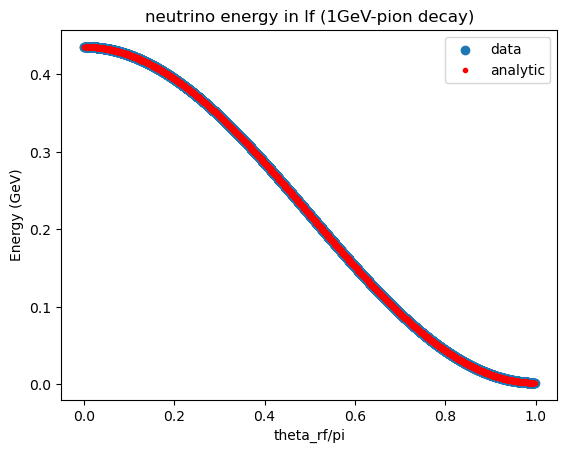

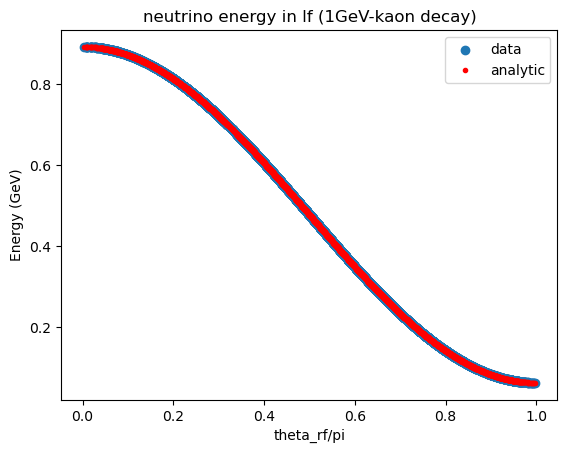

### Bugs found in Section 3.1c

Only minor changes were made to the following snippets:

In [ ]:
plt.ylabel('N')
plt.xlabel('energy (MeV)')





plt.ylabel('N')
plt.xlabel('energy (MeV)')

which were modified to reflect correct units and include an explanation of what N is:

In [ ]:
plt.ylabel('Frequency N')
plt.xlabel('energy (GeV)')





plt.ylabel('Frequency N')
plt.xlabel('energy (GeV)')

The plots showed uniform distributions with each bar having a frequency of around 1000. They also had the correct max/min energies as calculated in 2.4. The uniform shape comes from the fact that each lab frame energy was equally likely for the neutrini, stemming from the original generation of theta values being random - and the stochastic nature of particle decays. These random theta values were required to get the neutrino energies, making them random too. Also, boosting to lab frame spreads the frequencies of different angles out into a uniform distribution - so e.g. the more likely angle of $\theta = \pi/2$ in the rest frame spreads out to other angles. The plots were:

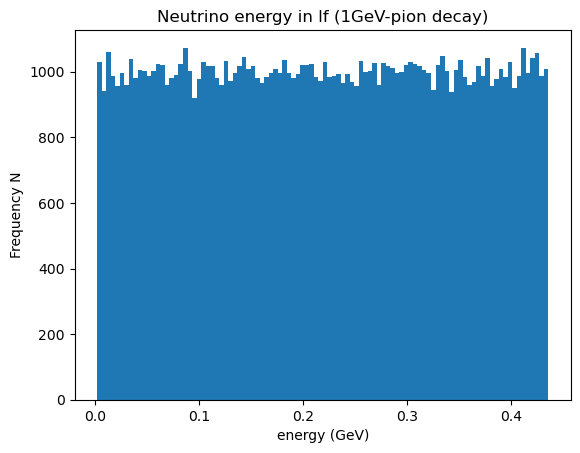
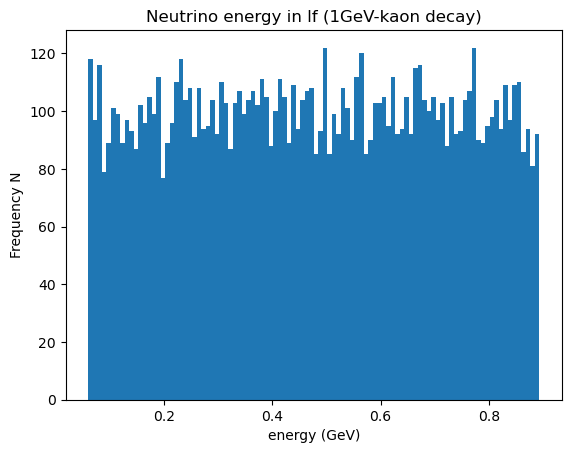

### Bugs found in Section 3.1d

Code snippets that were originally written, that I went on to change were:

In [ ]:
plt.hist(theta_rf_pi, bins = 100, log=True)
plt.ylabel('N')




plt.hist(theta_rf_K, bins = 100, log=True)
plt.ylabel('N')


The code was using the rest frame theta values, but should have used the lab frame values. To find these, I Lorentz-transformed them back to lab frame using the equation $\cos\theta'=\frac{\cos\theta-\beta}{1-\beta\cos\theta}$. The corrected code was:

In [ ]:
theta_lf_pi = np.arccos((np.cos(theta_rf_pi)-beta_v_pi)/(1-beta_v_pi*np.cos(theta_rf_pi)))

theta_lf_K = np.arccos((np.cos(theta_rf_K)-beta_v_K)/(1-beta_v_K*np.cos(theta_rf_K)))


plt.hist(theta_lf_pi, bins = 100, log=True)




plt.hist(theta_lf_K, bins = 100, log=True)

I also added 'Frequency' to the y axis titles for clarity:

In [ ]:
plt.ylabel('Frequency N')

The graphs showed appropriate distributions with logged y-axes.

### Bugs found in Section 3.2

The initial code snippets that I went on to change were:

In [ ]:
n_samples = 5000

#distribution of momentum values for pi decay
mtm_distrib_E_pi=generate_array(E_min, E_max, mu, sigma_pi, n_samples)

#distribution of momentum values for K decay 
mtm_distrib_E_K=generate_array(E_min, E_max, mu, sigma_K, n_samples)
   
plt.plot(mtm_distrib_E_pi,'.')
plt.xlabel('index')
plt.ylabel('p_pi (MeV/c)')




plt.hist(mtm_distrib_E_pi, bins = 100)
plt.xlabel('p_pi (MeV/c)')
plt.ylabel('N')
plt.title('Momentum distribution of pi particles')

Firstly, I assumed that energy also takes the form of the momentum log-normal distribution. If we input energies into the arguments of the generate_array function, it should produce an energy output; not momentum - contrary to one of the original comments. I also increased the number of samples to 10000 because more data is always better, while multiplying by 10 in the pi distribution to reflect the greater number of pion decays in the beam. There were issues with a disagreement between the number of array elements from previous functions, so I went back to change them. This was 3.1(a) - Erun_pi to 100000 and Erun_K to 10000. n_samples became:

In [ ]:
n_samples = 10000

The arguments E_min and E_max were incorrectly placed. The pions/kaons in the lab frame will have an energy greater than their rest energies - never 0, so E_min should have been $m_{pi/K}c^2$. The energy distributions (not momenta) were then written as:

In [ ]:
#distribution of momentum values for pi decay
energy_distrib_E_pi=generate_array(mpi, E_max, mu, sigma_pi, n_samples*10)
pi_4mtm = find4mtm_C_lf(mpi, mmu,mnu, theta_lf_pi, 0, energy_distrib_E_pi) #mention assumption that E approx mom dist



#distribution of momentum values for K decay 
energy_distrib_E_K=generate_array(mK, E_max, mu, sigma_K, n_samples)
K_4mtm = find4mtm_C_lf(mK, mmu,mnu, theta_lf_K, 0, energy_distrib_E_K)


Here, the 4-momenta of the neutrini were calculated using the find4mtm_C_lf function earlier defined, with the $\theta$ values generated in part 3.1(d), and $\phi=0$.

Next, I ammended the graphs to show the appropriate information, including titles, namely the energies of the neutrini - found by slicing their 4-momenta to the first element. I made sure to show both pion and kaon decays, since the kaon distribution was not previously shown. Here are the changed snippets:

In [ ]:
plt.plot(pi_4mtm_nu[0,:],'.')

plt.ylabel('E_neutrino_pi (MeV)')



plt.hist(pi_4mtm_nu[0,:], bins = 100)
plt.xlabel('E_neutrino_pi (MeV)')

plt.title('Energy distribution of neutrini pi decay in lab frame')





plt.plot(K_4mtm_nu[0,:],'.')

plt.ylabel('E_neutrino_K (MeV)')





plt.hist(K_4mtm_nu[0,:], bins = 100)
plt.xlabel('E_neutrino_K (MeV)')

plt.title('Energy distribution of neutrini K decay in lab frame')



The graphs showed sensible distributions, and reflected the correct max/min neutrino energies from part 2.4 if I put E_max as 1000 (1GeV like in previous parts) - giving me confidence in my code. Note I stopped ammending the histogram y axes from 'N' to 'frequency N', as I felt it was clear enough to myself what N meant by this point.

### Bugs found in Section 3.3a

Original code snippets that were written, which I went on to change were:

In [ ]:
EA_pi = mtm_distrib_E_pi





EA_K = mtm_distrib_E_K






theta_rf_pi=generate_theta_array(Nrun_pi)
theta_rf_K=generate_theta_array(Nrun_K)


phi_rf_pi = theta_rf_pi
phi_rf_K = theta_rf_K







energy_nu_lf_pi=gamma_v_pi*energy_nu_rf_pi - beta_v_pi*gamma_v_pi*p_rf_pi_ar[2,:]
    



    

energy_nu_lf_K=boosted4mtmar(m4nu_rf_K,beta_v_K)[0]

Firstly, EA_pi/K should have been the energy distributions from the previous part:

In [ ]:
EA_pi = energy_distrib_E_pi





EA_K = energy_distrib_E_K

Then, the arguments of generate_theta_array were wrong. It should have been as follows, to relect the domain of theta:

In [ ]:
theta_domain = [0,np.pi]
theta_rf_pi=generate_theta_array(Nrun_pi, theta_domain) #Added domain argument
theta_rf_K=generate_theta_array(Nrun_K, theta_domain)

Phi is not equal to theta - this is simply wrong. It is still $\phi = 0$, to reflect the fact that $y=0$ from part 1:

In [ ]:
#We choose phi as 0   
phi_rf_pi = 0
phi_rf_K = 0

Finally, the lab frame energies energy_nu_lf_pi/K were renamed to energy_nu_lf_pi2/K2 to not confuse with an earlier variable. The pion decay neutrino energy was changed to give the correct values using the boosted4mtmar function. It was previously trying to apply a Lorentz transformation, on the wrong component of the 4-momentum. My new code was:

In [ ]:
energy_nu_lf_pi2=boosted4mtmar(m4nu_rf_pi,beta_v_pi)[0]





energy_nu_lf_K2=boosted4mtmar(m4nu_rf_K,beta_v_K)[0]

which also sliced to the energy component of the 4-momentum. The next addition to my code was to add the histograms that were asked for:

In [ ]:
plt.hist(energy_nu_lf_pi2, bins = 100)
plt.xlabel('E_neutrino_pi (MeV)')
plt.ylabel('N') #Although I previously added 'frequency' to the histograms, I think it is clear enough what 'N' means by now
plt.title('Energy distribution of neutrini K decay in lab frame')
plt.show()




plt.hist(energy_nu_lf_K2, bins = 100)
plt.xlabel('E_neutrino_K (MeV)')
plt.ylabel('N') #Although I previously added 'frequency' to the histograms, I think it is clear enough what 'N' means by now
plt.title('Energy distribution of neutrini pi decay in lab frame')
plt.show()




### Bugs found in Section 3.3b

Original code snippets that were written, which I went on to amend were:

In [ ]:

Nevents,bins,patches=plt.hist(energy_nu_lf, bins = 100, range=[0,6], log=True, color='c')
plt.hist(energy_nu_rf_pi, bins=100, range=range_energy, log=True, histtype='step', linewidth=2, label='pi')
plt.hist(energy_nu_rf_K, bins=100, range=range_energy, log=True, histtype='step', linewidth=2, label='K')

plt.xlabel('Energy (GeV)')


The first calling of plt.hist() had the wrong range. The range was already found as range_energy. The next two plt.hist() callings had the incorrect energies. The instructions asked for lab frame energies, so I changed this accordingly. The instructions also asked for a log scale for energy, not for the number of events. I changed log=True to log=False to reflect this, adding plt.xscale('log') to give logged energies. I did not think the histtype='step' style helped visually, so I removed this along with its corresponding linewidth=2. I modified the labels too: 

In [ ]:
Nevents,bins,patches=plt.hist(energy_nu_lf, bins = 100, range=range_energy, log=False, color='c', label='combined decays')
plt.hist(energy_nu_lf_pi, bins=100, range=range_energy, log=False,  label='pion decay')
plt.hist(energy_nu_lf_K, bins=100, range=range_energy, log=False, label='kaon decay')

plt.xscale('log')

Energies were in logged MeV, so I changed this too.

In [ ]:
plt.xlabel('log Energy (MeV)')

The resulting histogram was:

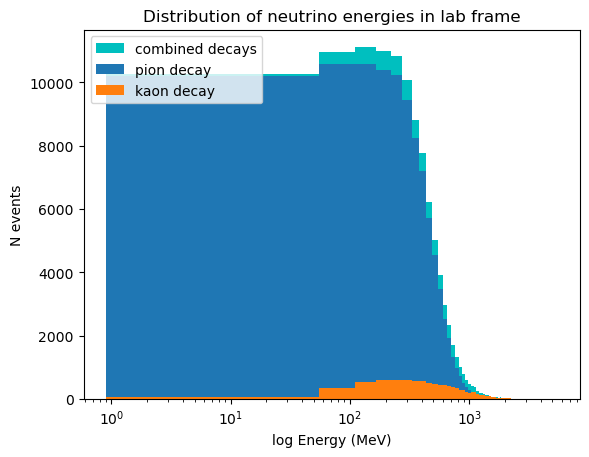

### Bugs found in Section 3.3c

The code which was originally written, that I went on to change was:

In [ ]:

Nevents,bins,patches=plt.hist(theta_nu_lf, bins = 100, range=[0,6], log=True, color='c')
plt.hist(theta_lf_pi, bins=100, range=[0,6], log=True, histtype='step', linewidth=2, label='pi')
plt.hist(theta_lf_K, bins=100, range=[0,6], log=True, histtype='step', linewidth=2, label='K')


This used the wrong ranges, and should have used the range_theta already defined. I also added a label to the combined decays histogram and ammended the pi/K labels. I also removed histtype='step' and corresponding linewidth=2 as I felt it did not help visually. My corrected code was:

In [ ]:
Nevents,bins,patches=plt.hist(theta_nu_lf, bins = 100, range=range_theta, log=True, color='c', label = 'combined decays')
plt.hist(theta_lf_pi, bins=100, range=range_theta, log=True, label='pion decay')
plt.hist(theta_lf_K, bins=100, range=range_theta, log=True, label='kaon decay')


I kept the logged y-axis as I felt it was appropriate for the data.

### Bugs found in Section 3.3d

The only change here was to reflect an earlier renaming to distinguish different arrays, and changing GeV to MeV:

In [ ]:
energy_nu_lf_pi


energy_nu_lf_K



plt.ylabel('energy (GeV)')

to:

In [ ]:
energy_nu_lf_pi2


energy_nu_lf_K2



plt.ylabel('energy (MeV)')

### Bugs found in Section 3.3e

It would be much more difficult to use 3.3(c) to differentiate the two decays. This is because the pion and kaon histograms overlap. It is given that there are 10x more pion decays overall, so the histogram does not really add any new information. It could be used to distinguish the two at low angles less than around 0.4 radians - noting the distortion of the log scale. Here, there is much greater probability of any decay being from a pion - but it would be impossible to distinguish the two with certainty.

It would be much easier to use 3.3(d) to differentiate the two decays. There is a clear difference between the pion/kaon distributions in the neutrini. It is only at low values of lab frame theta that the two overlap, where it would be difficult to distinguish them by their energies. However, at theta values greater than around 0.2 radians, the two diverge, meaning one could easily determine what the parent particle was by measuring a high or low energy for a given theta.